In [46]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures

plt.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}"
plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text',usetex=True)

import julia
from julia import Main
from julia import Distributed
Main.eval("using QuadGK")

In [47]:
Main.include("..\\strong coupling\\constants.jl")
Main.include("..\\strong coupling\\alpha_s.jl")
Main.include("..\\splitting\\moments.jl")
Main.include("..\\hard\\hard.jl")
Main.include("..\\jet\\jet.jl")
Main.include("..\\cross section.jl")

Main.include("..\\fixed order\\analytic.jl")
Main.include("..\\fixed order\\perturbative EEC.jl")
Main.include("..\\fixed order\\SCET.jl")
Main.include("..\\fixed order\\non-singular.jl")

Main.include("..\\cross section.jl")
Main.include("..\\diff eqn.jl")
Main.include("..\\NP.jl")

In [49]:
import pandas as pd
import numpy as np

χ_lower = 1.0
χ_upper = 179

#-------------------------------------------------------------------
dataset_names = ["OPAL"]
#-------------------------------------------------------------------
#-------------------------------------------------------------------
dataset_names = ["OPAL","SLD","TOPAZ_595","TOPAZ_533",
                 "TASSO_435","TASSO_348","MARKII","MAC"]
#-------------------------------------------------------------------

dataset_qua = ["OPAL_new","OPAL","MAC"]  
 
df_qua = {}

for name in dataset_qua:
    file_path = f"../data/{name}.csv"
    df = pd.read_csv(file_path)
    
    χ = df["CHI"]
    EEC = df["EEC"]
    ERROR = df["STAT"]
    
    df1 = pd.DataFrame({"CHI": χ, "EEC": EEC, "ERROR": ERROR})
    df_qua[name] = df1

dataset_ss = ["SLD","DELPHI","TOPAZ_595","TOPAZ_533","TASSO_435","TASSO_348","MARKII"]

df_ss = {}

for name in dataset_ss:
    file_path = f"../data/{name}.csv"
    df = pd.read_csv(file_path)
    
    χ = df["CHI"]
    EEC = df["EEC"]
    ERROR = np.sqrt(df["STAT"]**2+df["SYS"]**2)
    
    df1 = pd.DataFrame({"CHI": χ, "EEC": EEC, "ERROR": ERROR})
    df_ss[name] = df1

df = df_qua
df.update(df_ss)

df_truncated = {}
χ_list = {}
EEC = {}
ERROR = {}

Q_list = {}
Q_list["SLD"]       = 91.2
Q_list["OPAL"]      = 91.2
Q_list["OPAL_new"]      = 91.2
#Q_list["OPAL"]      = 500.0
Q_list["DELPHI"]    = 91.2
Q_list["TOPAZ_595"] = 59.5
Q_list["TOPAZ_533"] = 53.3
Q_list["TASSO_435"] = 43.5
Q_list["TASSO_348"] = 34.8
Q_list["MARKII"]    = 29.0
Q_list["MAC"]       = 29.0

for name in dataset_names:
    df_truncated[name] = df[name][(df[name]["CHI"] <= χ_upper) & (df[name]["CHI"] >= χ_lower)]

    χ_list[name] = np.array(df_truncated[name]["CHI"])
    EEC[name] = np.array(df_truncated[name]["EEC"])
    ERROR[name] = np.array(df_truncated[name]["ERROR"])

In [50]:
import pandas as pd

xlist = np.linspace(5,175,1000)

analytic_LO = []
analytic_NLO = []

df_LO = pd.read_csv("EECLO.csv",header=None)
df_NLO = pd.read_csv("EECNLO.csv",header=None)
df_NNLO = pd.read_csv("EECNNLO.csv",header=None)

CHI_LO = df_LO.iloc[:, 0]
CHI_NLO = df_NLO.iloc[:, 0]
CHI_NNLO = df_NNLO.iloc[:, 0]

numerical_LO = df_LO.iloc[:, 1]
numerical_NLO = df_NLO.iloc[:, 1]
numerical_NNLO = df_NNLO.iloc[:, 1]

ERROR_LO = df_LO.iloc[:, 2]
ERROR_NLO = df_NLO.iloc[:, 2]
ERROR_NNLO = df_NNLO.iloc[:, 2]

for χ in xlist:
    angle = χ*np.pi/180
    z = 0.5*(1-np.cos(angle))

    LO = Main.A_func(z)*np.sin(angle)
    NLO = Main.B_func(z)*np.sin(angle)

    analytic_LO.append(LO)
    analytic_NLO.append(NLO)

In [51]:
(4*np.pi)/(128**2*3*91.2**2)*(3.8937966*10**(8))*(3*11/9)*np.pi/180

0.7659511154123639

In [ ]:
/np.sin(CHI_NLO*np.pi/180)*(1-np.cos(CHI_NLO*np.pi/180))

(0.0, 30.0)

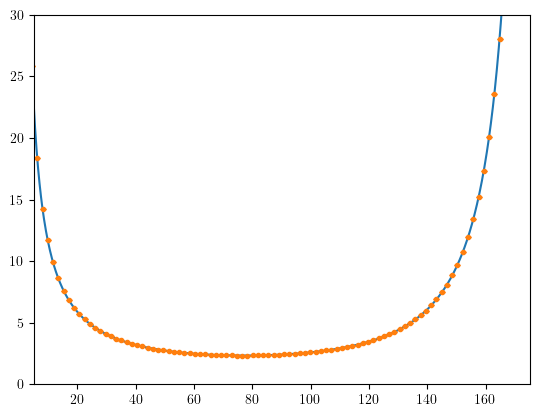

In [58]:
plt.plot(xlist,analytic_LO)
plt.errorbar(CHI_LO, numerical_LO, yerr=ERROR_LO, fmt='o', capsize=2, markersize=3)
plt.xlim(5,175)
plt.ylim(0,30)

(0.0, 600.0)

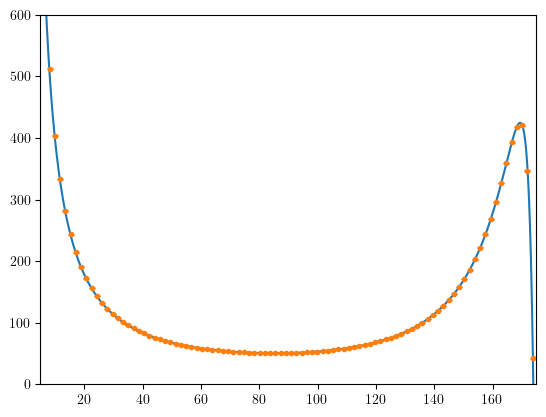

In [53]:
plt.plot(xlist,analytic_NLO)
plt.errorbar(CHI_NLO, numerical_NLO, yerr=ERROR_NLO, fmt='o', capsize=2, markersize=3)
plt.xlim(5,175)
plt.ylim(0,600)

(0.0, 8000.0)

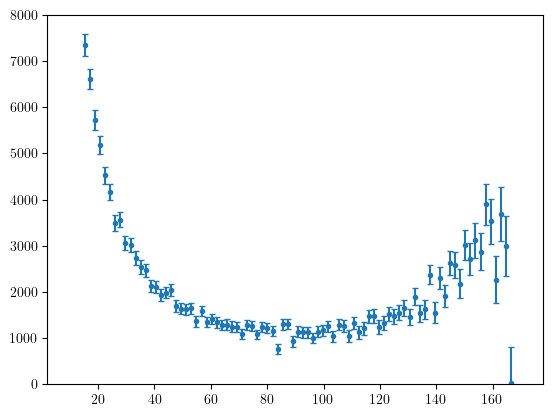

In [54]:
plt.errorbar(CHI_NNLO, numerical_NNLO, yerr=ERROR_NNLO, fmt='o', capsize=2, markersize=3)
plt.xlim(2,178)
plt.ylim(0,8000)

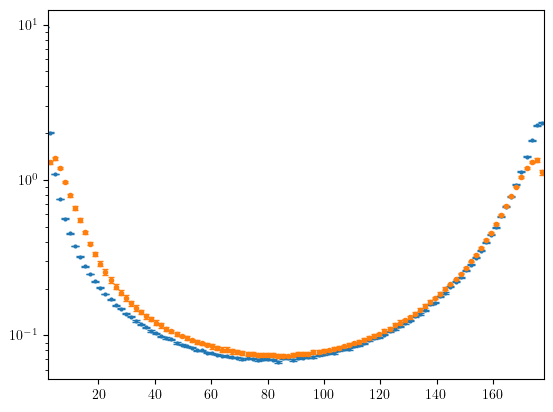

In [57]:
a=0.118/(2*np.pi)
EEC_numerical=a*numerical_LO+a**2*numerical_NLO+a**3*numerical_NNLO
plt.errorbar(CHI_NNLO, EEC_numerical, yerr=a**3*ERROR_NNLO, fmt='o', capsize=3, markersize=2)

data_chi = χ_list["OPAL"]                             # data x-values
data_y = EEC["OPAL"]
data_err = ERROR["OPAL"]   
plt.errorbar(data_chi, data_y, yerr=data_err, fmt='o', capsize=2, markersize=3, label='Data')

plt.xlim(2,178)
#plt.ylim(0,3)
plt.yscale("log")